# Assignment 5 — K-Means Clustering and Initialization (k-means++)

**Course:** Statistical Methods for Machine Learning — A.Y. 2025/26  
**Paper:** *k-means++: The Advantages of Careful Seeding* — Arthur & Vassilvitskii, SODA 2007

---

## Objective

Compare standard **k-means** (random initialization) against **k-means++** (D²-seeding) across 50 independent trials.  
We measure **inertia** (within-cluster sum of squares) and **stability** (variance across trials) on three settings:
- Synthetic well-separated clusters
- Synthetic overlapping clusters
- MNIST (high-dimensional)

Both algorithms are implemented **from scratch using NumPy only**.


# 1. Imports & Synthetic Data
We generate 500 points from 5 Gaussian blobs (`cluster_std=1.0`) using `make_blobs`.  
The 2D structure lets us visualize clustering quality directly.  
Ground truth labels `y_blob` are only used for this initial plot, never passed to the algorithms.

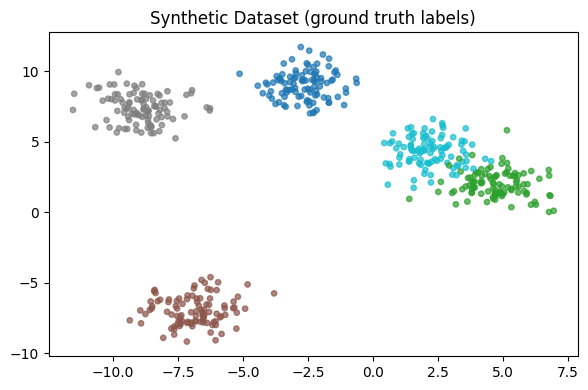

Shape: (500, 2)


In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import time

os.makedirs("figures", exist_ok=True)

X_blob, y_blob = make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=42)
plt.figure(figsize=(6, 4))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='tab10', s=15, alpha=0.7)
plt.title("Synthetic Dataset (ground truth labels)")
plt.tight_layout()
plt.show()
print("Shape:", X_blob.shape)


# 2. k-means implementation
1. Pick `k` random points from `X` as initial centroids
2. Repeat until convergence:
   - Assign each point to its nearest centroid
   - Update each centroid as the mean of its assigned points
3. Return centroids, labels, and inertia

> **Empty cluster guard**: if a centroid gets no assigned points, it keeps its previous position.

In [28]:
def kmeans(X, k, max_iter=300, seed=None):
    rng = np.random.default_rng(seed)
    # 1. Random init: pick k points as centroids
    idx = rng.choice(len(X), size=k, replace=False)
    centroids = X[idx].copy()

    for _ in range(max_iter):
        # 2a. Assign each point to nearest centroid
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)  # (n, k)
        labels = np.argmin(dists, axis=1)

        # 2b. Update centroids
        #new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j] for j in range(k)])


        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    inertia = np.sum((X - centroids[labels]) ** 2)
    return centroids, labels, inertia


# 3. k-means++
Same as k-means but with a smarter initialization:
1. Pick the first centroid uniformly at random
2. For each subsequent centroid, sample with probability proportional to $D(x)^2$, the squared distance to the nearest already-chosen centroid
3. Run standard k-means from step 2

In [29]:
def kmeans_plusplus_init(X, k, rng):
    # Pick first centroid uniformly at random
    centroids = [X[rng.choice(len(X))]]

    for _ in range(k - 1):
        # D(x) = squared distance to nearest chosen centroid
        D = np.min([np.sum((X - c) ** 2, axis=1) for c in centroids], axis=0)
        probs = D / D.sum()
        centroids.append(X[rng.choice(len(X), p=probs)])

    return np.array(centroids)

def kmeans_plusplus(X, k, max_iter=300, seed=None):
    rng = np.random.default_rng(seed)
    centroids = kmeans_plusplus_init(X, k, rng)

    for _ in range(max_iter):
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)
        labels = np.argmin(dists, axis=1)
        #new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j] for j in range(k)])

        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    inertia = np.sum((X - centroids[labels]) ** 2)
    return centroids, labels, inertia


## Utils x plotting

In [30]:
def plot_inertia_comparison(inertias_km, inertias_kpp, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, inertias, label, color in zip(
        axes,
        [inertias_km, inertias_kpp],
        ['k-means (random init)', 'k-means++'],
        ['steelblue', 'seagreen']
    ):
        ax.hist(inertias, bins=15, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(inertias.mean(), color='red', linestyle='--', label=f'Mean={inertias.mean():.0f}')
        ax.set_title(label)
        ax.set_xlabel("Inertia")
        ax.legend()

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"k-means   — mean: {inertias_km.mean():.1f}, std: {inertias_km.std():.1f}")
    print(f"k-means++ — mean: {inertias_kpp.mean():.1f}, std: {inertias_kpp.std():.1f}")


In [31]:
def plot_inertia_boxplot(inertias_km, inertias_kpp, title, save_path=None):
    plt.figure(figsize=(7, 5))
    plt.boxplot([inertias_km, inertias_kpp], tick_labels=['k-means', 'k-means++'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
    plt.title(title)
    plt.ylabel("Inertia")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"k-means   — mean: {inertias_km.mean():.1f}, variance: {inertias_km.var():.0f}")
    print(f"k-means++ — mean: {inertias_kpp.mean():.1f}, variance: {inertias_kpp.var():.0f}")


# 4. Experiment 1: Synthetic Dataset: 50 Trials (k=5)

We run both algorithms **50 times** with seeds (0–49).  
For each run we record the **inertia** at convergence:

$$\mathcal{L} = \sum_{i=1}^{n} \min_{j} \| x_i - \mu_j \|^2$$

Lower is better. We show:
- **Histogram** — distribution of inertia outcomes across trials
- **Boxplot** — stability comparison (spread and outliers)


In [32]:
N_TRIALS = 50
K = 5

inertias_km = []
inertias_kpp = []

for seed in range(N_TRIALS):
    _, _, inertia = kmeans(X_blob, K, seed=seed)
    inertias_km.append(inertia)
    _, _, inertia = kmeans_plusplus(X_blob, K, seed=seed)
    inertias_kpp.append(inertia)

inertias_km = np.array(inertias_km)
inertias_kpp = np.array(inertias_kpp)

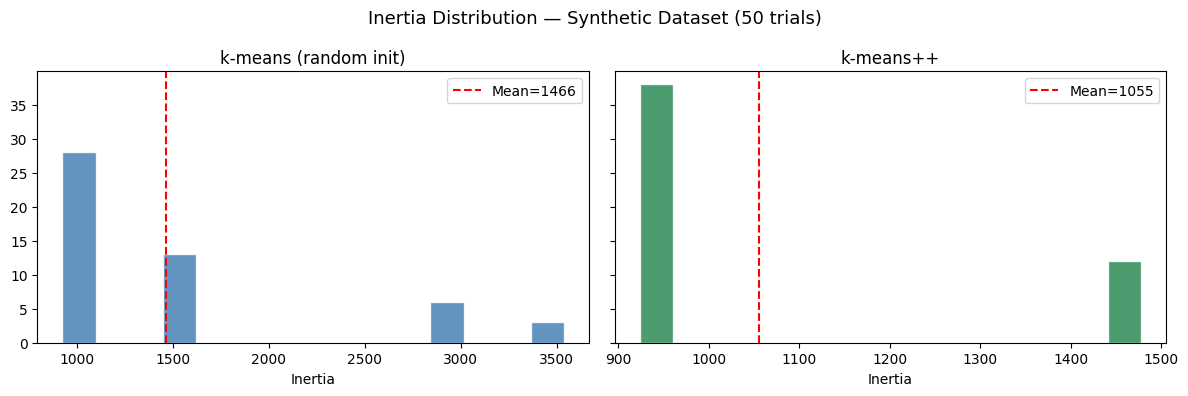

k-means   — mean: 1466.1, std: 825.7
k-means++ — mean: 1055.5, std: 233.9


In [33]:
# Experiment 1 — Synthetic
plot_inertia_comparison(inertias_km, inertias_kpp, "Inertia Distribution — Synthetic Dataset (50 trials)", save_path="figures/hist_synthetic.png")

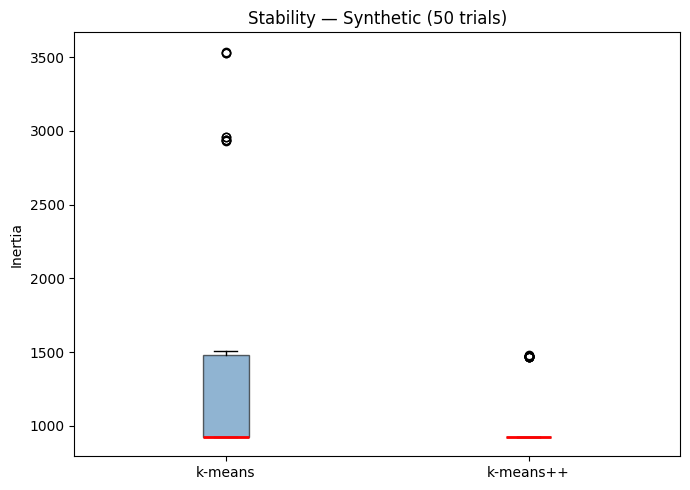

k-means   — mean: 1466.1, variance: 681836
k-means++ — mean: 1055.5, variance: 54718


In [34]:
plot_inertia_boxplot(inertias_km, inertias_kpp, "Stability — Synthetic (50 trials)", save_path="figures/box_synthetic.png")

## Best Run Cluster Visualization
We visualize the **best run** (lowest inertia seed) for each algorithm on the synthetic dataset.  
Red ✕ markers are the final centroid positions.

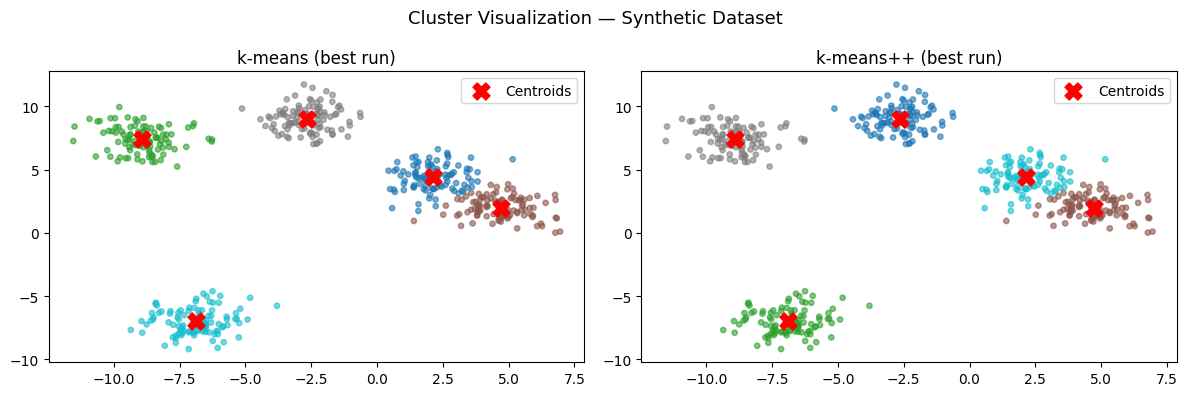

In [35]:
best_km_seed = int(np.argmin(inertias_km))
best_kpp_seed = int(np.argmin(inertias_kpp))

centroids_km, labels_km, _ = kmeans(X_blob, K, seed=best_km_seed)
centroids_kpp, labels_kpp, _ = kmeans_plusplus(X_blob, K, seed=best_kpp_seed)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, centroids, title in zip(
    axes,
    [labels_km, labels_kpp],
    [centroids_km, centroids_kpp],
    ["k-means (best run)", "k-means++ (best run)"]
):
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap='tab10', s=15, alpha=0.6)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=150, zorder=5, label='Centroids')
    ax.set_title(title)
    ax.legend()

plt.suptitle("Cluster Visualization — Synthetic Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("figures/clusters_synthetic.png", dpi=150, bbox_inches='tight')
plt.show()


# 5. Experiment 2: High-Dimensional (MNIST, k=10)

We test whether k-means++ retains its advantage in high dimensions.

**Dataset:** MNIST handwritten digits — first 5000 samples, 784 features (28×28 pixels), normalized to [0, 1].  
**k = 10** (one cluster per digit class). No train/test split — clustering is fully unsupervised.

In high dimensions, pairwise distances concentrate around their mean (curse of dimensionality), so the D²-sampling of k-means++ becomes nearly uniform — we expect the gap to shrink significantly.

We show:
- **Histogram** — distribution of inertia outcomes across 50 trials
- **Boxplot** — stability comparison


In [36]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

n_samples=5000

X_mnist = X[:n_samples].astype(float) / 255.0
y_mnist = y[:n_samples].astype(int)

print("MNIST subset shape:", X_mnist.shape)


MNIST subset shape: (5000, 784)


In [37]:
# Convert labels (y) from strings to integers
y = y.astype(int)
print(f"Labels shape (y): {y.shape}")
print(f"Clustering {n_samples} samples into {len(np.unique(y))} clusters...")

Labels shape (y): (70000,)
Clustering 5000 samples into 10 clusters...


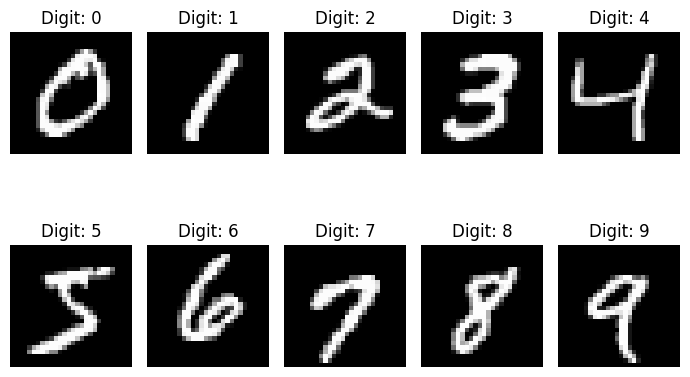

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(7, 5))
for digit, ax in enumerate(axes.flat):
    ax.imshow(X[np.where(y.astype(int) == digit)[0][0]].reshape(28, 28), cmap='gray')
    ax.set_title(f"Digit: {digit}")
    ax.axis('off')
plt.tight_layout()
plt.show()


In [39]:
K_mnist = 10
inertias_km_mnist = []
inertias_kpp_mnist = []

start_time = time.time()

for seed in range(N_TRIALS):
    _, _, inertia = kmeans(X_mnist, K_mnist, seed=seed)
    inertias_km_mnist.append(inertia)
    _, _, inertia = kmeans_plusplus(X_mnist, K_mnist, seed=seed)
    inertias_kpp_mnist.append(inertia)

end_time = time.time()

print(f"K-Means & K-Means++ training finished in {end_time - start_time:.2f} seconds.")

inertias_km_mnist = np.array(inertias_km_mnist)
inertias_kpp_mnist = np.array(inertias_kpp_mnist)


K-Means & K-Means++ training finished in 126.47 seconds.


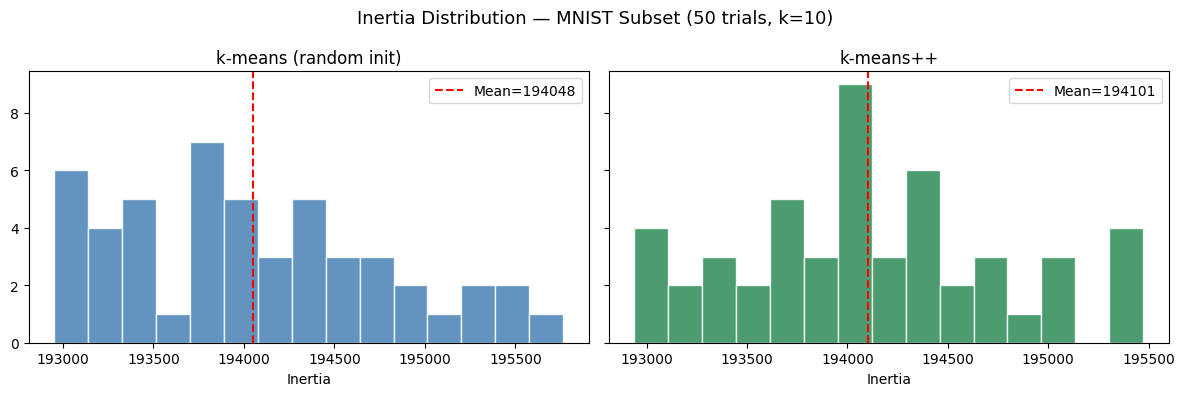

k-means   — mean: 194047.8, std: 743.4
k-means++ — mean: 194101.1, std: 663.0


In [40]:
plot_inertia_comparison(inertias_km_mnist, inertias_kpp_mnist, "Inertia Distribution — MNIST Subset (50 trials, k=10)", save_path="figures/hist_mnist.png")

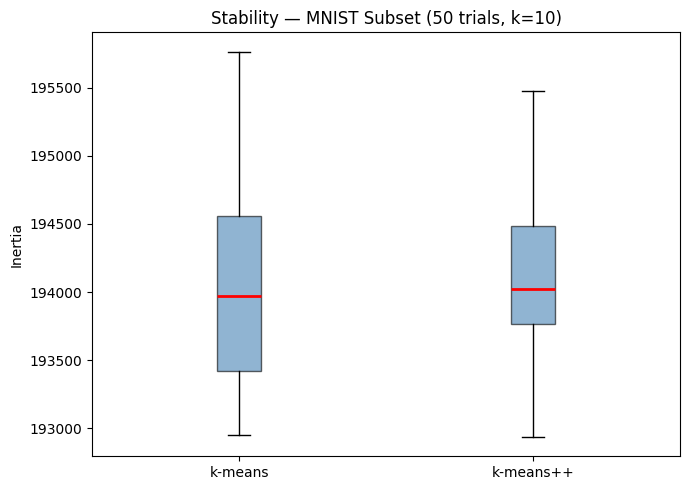

k-means   — mean: 194047.8, variance: 552700
k-means++ — mean: 194101.1, variance: 439531


In [41]:
plot_inertia_boxplot(inertias_km_mnist, inertias_kpp_mnist, "Stability — MNIST Subset (50 trials, k=10)", save_path="figures/box_mnist.png")

### Results — MNIST (784 dims, k=10)
| | k-means | k-means++ |
|---|---|---|
| Mean inertia | 194,047.8 | 194,101.1 |
| Std | 743.4 | 663.0 |
| Variance | 552,643 | 439,969 |

No meaningful difference — curse of dimensionality eliminates the advantage.


# 6. Results So Far

| Setting | km mean | kpp mean | km std | kpp std |
|---|---|---|---|---|
| Synthetic (std=1.0) | 1466.1 | **1055.5** | 825.7 | **233.9** |
| MNIST (784 dims) | 194,047.8 | 194,101.1 | 743.4 | 663.0 |

k-means++ dominates on well-separated clusters but loses its advantage in high dimensions.  

**Question:** what if clusters overlap in low dimensions — does geometry still help?


In [42]:
print("=" * 55)
print(f"{'':25} {'k-means':>10} {'k-means++':>10}")
print("=" * 55)
print(f"{'Synthetic mean':25} {inertias_km.mean():>10.1f} {inertias_kpp.mean():>10.1f}")
print(f"{'Synthetic std':25} {inertias_km.std():>10.1f} {inertias_kpp.std():>10.1f}")
print("-" * 55)
print(f"{'MNIST mean':25} {inertias_km_mnist.mean():>10.1f} {inertias_kpp_mnist.mean():>10.1f}")
print(f"{'MNIST std':25} {inertias_km_mnist.std():>10.1f} {inertias_kpp_mnist.std():>10.1f}")
print("=" * 55)


                             k-means  k-means++
Synthetic mean                1466.1     1055.5
Synthetic std                  825.7      233.9
-------------------------------------------------------
MNIST mean                  194047.8   194101.1
MNIST std                      743.4      663.0


# 7. Experiment 3: Overlapping Clusters (k=5, std=3.0)

We re-run with heavily overlapping blobs, when many partitions achieve similar inertia, we expect initialization strategy to matter less.


In [43]:
X_overlap, y_overlap = make_blobs(n_samples=500, centers=5, cluster_std=3.0, random_state=42)

inertias_km_ov = []
inertias_kpp_ov = []

for seed in range(N_TRIALS):
    _, _, inertia = kmeans(X_overlap, K, seed=seed)
    inertias_km_ov.append(inertia)
    _, _, inertia = kmeans_plusplus(X_overlap, K, seed=seed)
    inertias_kpp_ov.append(inertia)

inertias_km_ov = np.array(inertias_km_ov)
inertias_kpp_ov = np.array(inertias_kpp_ov)

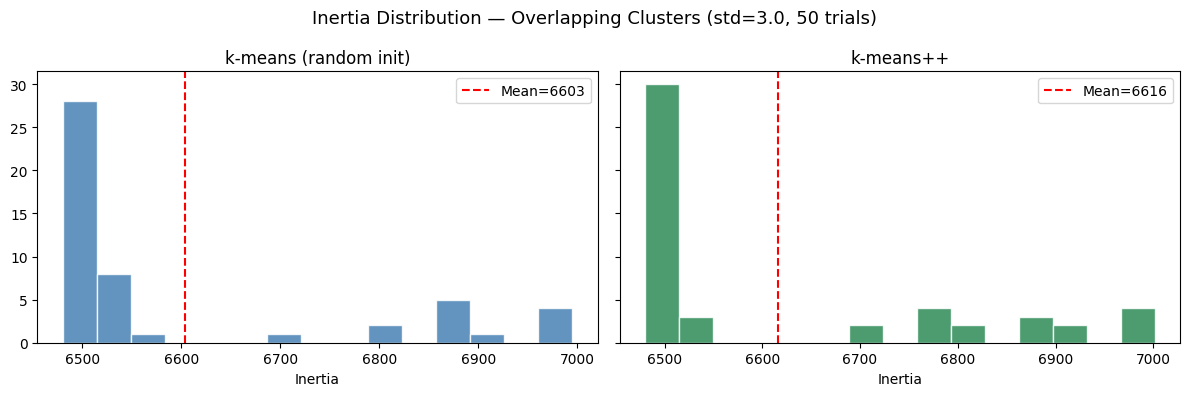

k-means   — mean: 6603.5, std: 177.6
k-means++ — mean: 6615.9, std: 184.4


In [44]:
plot_inertia_comparison(inertias_km_ov, inertias_kpp_ov, "Inertia Distribution — Overlapping Clusters (std=3.0, 50 trials)", save_path="figures/hist_overlap.png")

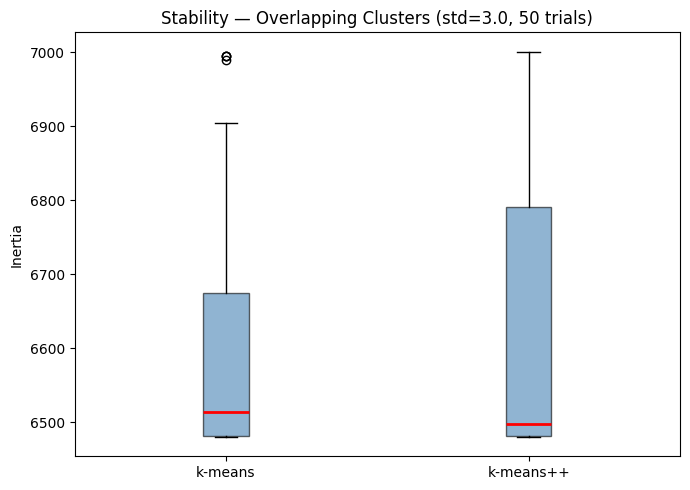

k-means   — mean: 6603.5, variance: 31526
k-means++ — mean: 6615.9, variance: 34013


In [45]:
plot_inertia_boxplot(inertias_km_ov, inertias_kpp_ov, "Stability — Overlapping Clusters (std=3.0, 50 trials)", save_path="figures/box_overlap.png")

## Cluster Visualization: Overlapping Case

Comparing the **worst k-means run** (highest inertia seed) against the **best k-means++** run.  
With overlapping geometry, even the "worst" and "best" runs look qualitatively similar, confirming that no initialization strategy has a clear geometric advantage here.


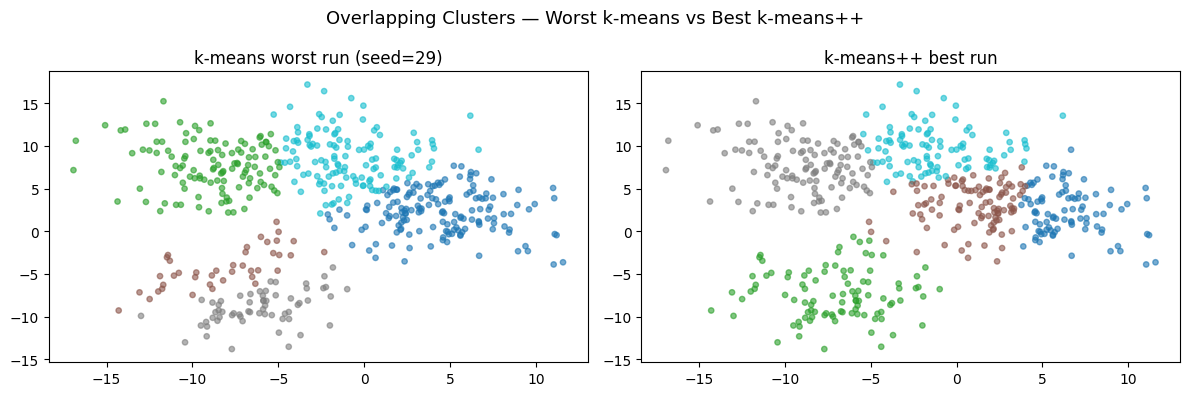

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

worst_km_seed = int(np.argmax(inertias_km_ov))
_, labels_best_kpp, _ = kmeans_plusplus(X_overlap, K, seed=int(np.argmin(inertias_kpp_ov)))
_, labels_worst_km, _ = kmeans(X_overlap, K, seed=worst_km_seed)

axes[0].scatter(X_overlap[:, 0], X_overlap[:, 1], c=labels_worst_km, cmap='tab10', s=15, alpha=0.6)
axes[0].set_title(f"k-means worst run (seed={worst_km_seed})")

axes[1].scatter(X_overlap[:, 0], X_overlap[:, 1], c=labels_best_kpp, cmap='tab10', s=15, alpha=0.6)
axes[1].set_title("k-means++ best run")

plt.suptitle("Overlapping Clusters — Worst k-means vs Best k-means++", fontsize=13)
plt.tight_layout()
plt.savefig("figures/clusters_overlap.png", dpi=150, bbox_inches='tight')
plt.show()


# Final Analysis

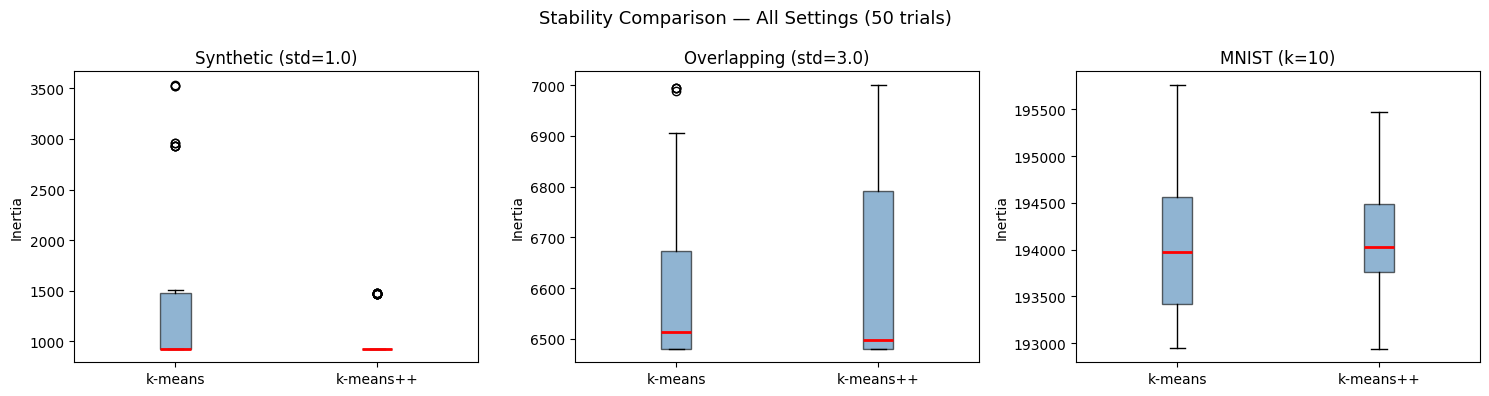

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, (km, kpp), title in zip(
    axes,
    [(inertias_km, inertias_kpp), (inertias_km_ov, inertias_kpp_ov), (inertias_km_mnist, inertias_kpp_mnist)],
    ['Synthetic (std=1.0)', 'Overlapping (std=3.0)', 'MNIST (k=10)']
):
    ax.boxplot([km, kpp], tick_labels=['k-means', 'k-means++'], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(title)
    ax.set_ylabel("Inertia")

plt.suptitle("Stability Comparison — All Settings (50 trials)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/box_all.png", dpi=150, bbox_inches='tight')
plt.show()


In [48]:
print("=" * 65)
print(f"{'Setting':25} {'km mean':>10} {'kpp mean':>10} {'km std':>8} {'kpp std':>8}")
print("=" * 65)
print(f"{'Synthetic (std=1.0)':25} {inertias_km.mean():>10.1f} {inertias_kpp.mean():>10.1f} {inertias_km.std():>8.1f} {inertias_kpp.std():>8.1f}")
print(f"{'Overlapping (std=3.0)':25} {inertias_km_ov.mean():>10.1f} {inertias_kpp_ov.mean():>10.1f} {inertias_km_ov.std():>8.1f} {inertias_kpp_ov.std():>8.1f}")
print(f"{'MNIST (784 dims)':25} {inertias_km_mnist.mean():>10.1f} {inertias_kpp_mnist.mean():>10.1f} {inertias_km_mnist.std():>8.1f} {inertias_kpp_mnist.std():>8.1f}")
print("=" * 65)


Setting                      km mean   kpp mean   km std  kpp std
Synthetic (std=1.0)           1466.1     1055.5    825.7    233.9
Overlapping (std=3.0)         6603.5     6615.9    177.6    184.4
MNIST (784 dims)            194047.8   194101.1    743.4    663.0


# 8. Sanity Check: sklearn KMeans vs Custom Implementation

We run `sklearn.cluster.KMeans` with `init='random'` and `init='k-means++'` on all three datasets and compare the **mean inertia** against our custom implementations to validate correctness.

> **Note:** sklearn uses `k-means++` by default and applies several internal optimizations (e.g. multiple restarts via `n_init`). Here we set `n_init=1` to make the comparison fair — one trial per seed.


In [49]:
from sklearn.cluster import KMeans as SKLearnKMeans

def compare_sklearn(X, k, n_trials=50, dataset_label=""):
    sk_km_inertias = np.array([
        SKLearnKMeans(n_clusters=k, init='random', n_init=1, max_iter=300, random_state=s).fit(X).inertia_
        for s in range(n_trials)
    ])
    sk_kpp_inertias = np.array([
        SKLearnKMeans(n_clusters=k, init='k-means++', n_init=1, max_iter=300, random_state=s).fit(X).inertia_
        for s in range(n_trials)
    ])

    print(f"\n=== {dataset_label} ===")
    print(f"{'Method':<20} {'Mean (custom)':>15} {'Mean (sklearn)':>15} {'Std (custom)':>14} {'Std (sklearn)':>14}")
    print("-" * 80)

    return sk_km_inertias, sk_kpp_inertias


In [50]:
# Synthetic dataset
sk_km_blob, sk_kpp_blob = compare_sklearn(X_blob, K, dataset_label="Synthetic Dataset (k=5)")
for label, custom, sk in [("k-means (random)", inertias_km, sk_km_blob), ("k-means++", inertias_kpp, sk_kpp_blob)]:
    print(f"{label:<20} {custom.mean():>15.1f} {sk.mean():>15.1f} {custom.std():>14.1f} {sk.std():>14.1f}")



=== Synthetic Dataset (k=5) ===
Method                 Mean (custom)  Mean (sklearn)   Std (custom)  Std (sklearn)
--------------------------------------------------------------------------------
k-means (random)              1466.1          1530.8          825.7          709.1
k-means++                     1055.5          1001.2          233.9          191.2


In [51]:
# MNIST dataset
sk_km_mnist, sk_kpp_mnist = compare_sklearn(X_mnist, 10, dataset_label="MNIST (k=10)")
for label, custom, sk in [("k-means (random)", inertias_km_mnist, sk_km_mnist), ("k-means++", inertias_kpp_mnist, sk_kpp_mnist)]:
    print(f"{label:<20} {custom.mean():>15.1f} {sk.mean():>15.1f} {custom.std():>14.1f} {sk.std():>14.1f}")


=== MNIST (k=10) ===
Method                 Mean (custom)  Mean (sklearn)   Std (custom)  Std (sklearn)
--------------------------------------------------------------------------------
k-means (random)            194047.8        194063.8          743.4          640.2
k-means++                   194101.1        193905.4          663.0          635.6
